<a href="https://colab.research.google.com/github/Harshit-Gupta-2005/Recomendation_system_analysis_and_winner/blob/main/MovieLens_1M_Winners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MovieLens 1M — Winner Validation & Live Recommender

The six category winners from the MovieLens 100K comparative study are retrained on the full **MovieLens 1M** dataset (6,040 users · 3,706 movies · 1,000,209 ratings) to validate whether the 100K rankings hold at 10× scale.

**Models evaluated:**

| Model | Why it's here |
|---|---|
| **SVD** (TruncatedSVD) | Fastest matrix factorisation baseline |
| **NCF** | Strong BPR ranking on 100K |
| **WideDeep** | Overall 100K winner (NDCG@10) |
| **LightGCN** | Best GNN efficiency/accuracy tradeoff |
| **GraphSAGE** | 100K coverage winner |
| **TF-IDF** | Diversity winner + cold-start fallback |

> SVD++ is excluded from the 1M run — pure numpy BPR-SGD on 1M interactions would take several hours on Colab CPU. TruncatedSVD covers the matrix factorisation family.

The notebook ends with a **live CLI recommender** backed by the 1M winner.

---

## 1. Setup & Data

### Imports & Global Settings

In [ ]:
import os, re, time, warnings, zipfile
from pathlib import Path
from math import log2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, clear_output
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_sim

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('/content/ml-1m')
print('Imports OK')

Imports OK


### Download & Extract MovieLens 1M

In [ ]:
ZIP_PATH = '/content/ml-1m.zip'

if not DATA_DIR.exists():
    print('Downloading MovieLens 1M (~25 MB)...')
    os.system(f'wget -q --show-progress '
              f'https://files.grouplens.org/datasets/movielens/ml-1m.zip '
              f'-O {ZIP_PATH}')
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print('Done.')
else:
    print('Data already present.')

for fname in ['ratings.dat', 'movies.dat', 'users.dat']:
    fpath = DATA_DIR / fname
    assert fpath.exists(), f'Missing: {fname}'
    print(f'  {fname:15s}  {fpath.stat().st_size/1e6:.1f} MB')

Extracting...
Done.
  ratings.dat      24.6 MB
  movies.dat       0.2 MB
  users.dat        0.1 MB


### Load & Parse Raw Files

In [ ]:
# Ratings: UserID::MovieID::Rating::Timestamp
ratings = pd.read_csv(
    DATA_DIR / 'ratings.dat', sep='::', engine='python',
    names=['UserID','MovieID','Rating','Timestamp'],
    dtype={'UserID':np.int32,'MovieID':np.int32,'Rating':np.float32,'Timestamp':np.int64}
)
ratings['Datetime'] = pd.to_datetime(ratings['Timestamp'], unit='s')

# Movies: MovieID::Title::Genres
movies_raw = pd.read_csv(
    DATA_DIR / 'movies.dat', sep='::', engine='python',
    names=['MovieID','Title','Genres'], encoding='latin-1',
    dtype={'MovieID':np.int32}
)
year_pat = re.compile(r'\((\d{4})\)\s*$')
movies_raw['Year']      = movies_raw['Title'].str.extract(r'\((\d{4})\)\s*$').astype(float)
movies_raw['TitleClean']= movies_raw['Title'].str.replace(r'\s*\(\d{4}\)\s*$','',regex=True).str.strip()

# Users: UserID::Gender::Age::Occupation::Zip
users = pd.read_csv(
    DATA_DIR / 'users.dat', sep='::', engine='python',
    names=['UserID','Gender','Age','Occupation','Zip'],
    dtype={'UserID':np.int32}
)

print(f'Ratings : {len(ratings):,}')
print(f'Movies  : {len(movies_raw):,}')
print(f'Users   : {len(users):,}')
display(ratings.head(3))

Ratings : 1,000,209
Movies  : 3,883
Users   : 6,040


,UserID,MovieID,Rating,Timestamp,Datetime
0,1,1193,5.0000,978300760,2000-12-31 22:12:40
1,1,661,3.0000,978302109,2000-12-31 22:35:09
2,1,914,3.0000,978301968,2000-12-31 22:32:48


### Cleaning: Dedup, Filter, Normalise, Split

In [ ]:
# Keep latest rating per (user, movie) pair
ratings = (ratings.sort_values('Timestamp')
                  .drop_duplicates(subset=['UserID','MovieID'], keep='last')
                  .reset_index(drop=True))

# Filter: users with >= 20 ratings, movies with >= 10 ratings
u_counts = ratings.groupby('UserID').size()
m_counts = ratings.groupby('MovieID').size()
ratings  = ratings[ratings['UserID'].isin(u_counts[u_counts >= 20].index)]
ratings  = ratings[ratings['MovieID'].isin(m_counts[m_counts >= 10].index)]
ratings  = ratings.reset_index(drop=True)

# Feature engineering
ratings['RatingRaw']  = ratings['Rating']
ratings['RatingNorm'] = (ratings['Rating'] - 1.0) / 4.0

# Sequential integer IDs
unique_users  = sorted(ratings['UserID'].unique())
unique_movies = sorted(ratings['MovieID'].unique())
user2idx  = {uid: i for i, uid in enumerate(unique_users)}
movie2idx = {mid: i for i, mid in enumerate(unique_movies)}
idx2user  = {i: uid for uid, i in user2idx.items()}
idx2movie = {i: mid for mid, i in movie2idx.items()}

ratings['UserIdx']  = ratings['UserID'].map(user2idx).astype(int)
ratings['MovieIdx'] = ratings['MovieID'].map(movie2idx).astype(int)

# Merge movie metadata
movies = movies_raw[movies_raw['MovieID'].isin(unique_movies)].copy().reset_index(drop=True)
df     = ratings.merge(movies[['MovieID','TitleClean','Genres','Year']], on='MovieID', how='left')

N_USERS  = len(unique_users)
N_MOVIES = len(unique_movies)
print(f'After cleaning: {len(ratings):,} ratings | {N_USERS:,} users | {N_MOVIES:,} movies')
print(f'Sparsity: {1 - len(ratings)/(N_USERS*N_MOVIES):.4f}')

After cleaning: 998,539 ratings | 6,040 users | 3,260 movies
Sparsity: 0.9493


In [ ]:
# Time-based 80/10/10 split
df_sorted = df.sort_values('Timestamp').reset_index(drop=True)
n = len(df_sorted)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_df = df_sorted.iloc[:train_end].copy().reset_index(drop=True)
val_df   = df_sorted.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df  = df_sorted.iloc[val_end:].copy().reset_index(drop=True)

for _df in [train_df, val_df, test_df]:
    _df['UserIdx']  = _df['UserIdx'].astype(int)
    _df['MovieIdx'] = _df['MovieIdx'].astype(int)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')
display(pd.DataFrame({
    'Split': ['Train','Val','Test'],
    'Rows':  [len(train_df), len(val_df), len(test_df)],
    'Users': [train_df.UserID.nunique(), val_df.UserID.nunique(), test_df.UserID.nunique()],
    'Movies':[train_df.MovieID.nunique(), val_df.MovieID.nunique(), test_df.MovieID.nunique()],
}))

Train: 798,831  Val: 99,854  Test: 99,854


,Split,Rows,Users,Movies
0,Train,798831,5399,3258
1,Val,99854,1133,3173
2,Test,99854,1209,3212


---

## 2. Exploratory Data Analysis

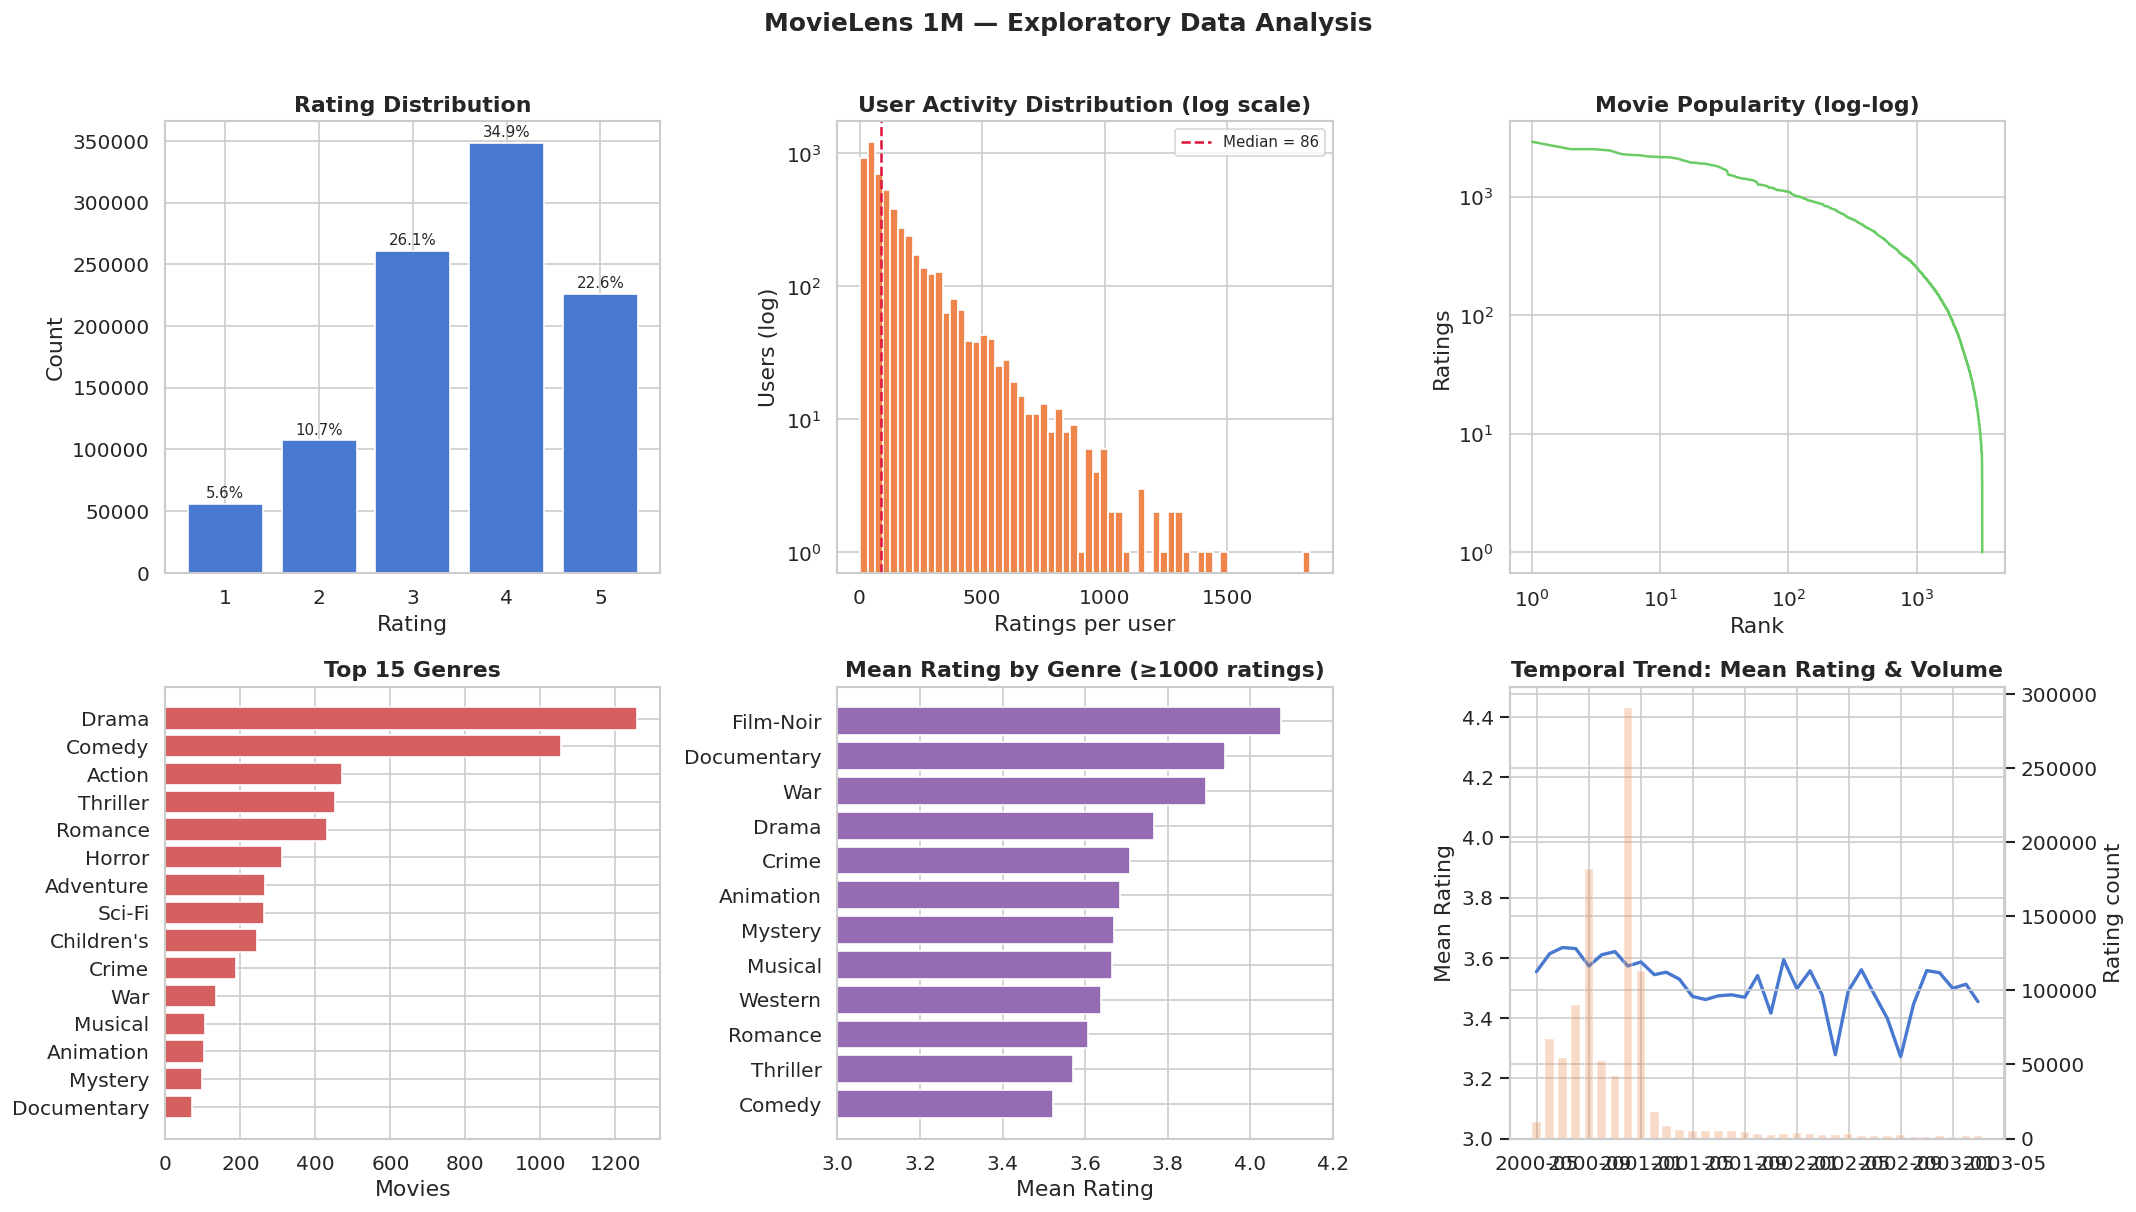

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Rating distribution
ax = axes[0,0]
vc = ratings['Rating'].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=sns.color_palette('muted')[0], edgecolor='white')
ax.set_title('Rating Distribution', fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
for x, y in zip(vc.index, vc.values):
    ax.text(x, y + 5000, f'{y/len(ratings)*100:.1f}%', ha='center', fontsize=9)

# 2. User activity distribution
ax = axes[0,1]
u_counts_clean = train_df.groupby('UserID').size()
ax.hist(u_counts_clean, bins=60, color=sns.color_palette('muted')[1],
        edgecolor='white', log=True)
ax.axvline(u_counts_clean.median(), color='crimson', linestyle='--',
           label=f'Median = {u_counts_clean.median():.0f}')
ax.set_title('User Activity Distribution (log scale)', fontweight='bold')
ax.set_xlabel('Ratings per user'); ax.set_ylabel('Users (log)')
ax.legend(fontsize=9)

# 3. Movie popularity distribution
ax = axes[0,2]
m_counts_clean = train_df.groupby('MovieID').size().sort_values(ascending=False)
ax.loglog(range(1, len(m_counts_clean)+1), m_counts_clean.values,
          color=sns.color_palette('muted')[2], linewidth=1.5)
ax.set_title('Movie Popularity (log-log)', fontweight='bold')
ax.set_xlabel('Rank'); ax.set_ylabel('Ratings')

# 4. Genre distribution
ax = axes[1,0]
genre_counts = (movies['Genres'].str.split('|')
                .explode().value_counts().head(15))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
        color=sns.color_palette('muted')[3], edgecolor='white')
ax.set_title('Top 15 Genres', fontweight='bold')
ax.set_xlabel('Movies')

# 5. Rating by genre (top 10)
ax = axes[1,1]
genre_ratings = (df.assign(Genre=df['Genres'].str.split('|'))
                   .explode('Genre')
                   .groupby('Genre')['RatingRaw']
                   .agg(['mean','count'])
                   .query('count >= 1000')
                   .sort_values('mean', ascending=False)
                   .head(12))
ax.barh(genre_ratings.index[::-1], genre_ratings['mean'][::-1],
        color=sns.color_palette('muted')[4], edgecolor='white')
ax.set_title('Mean Rating by Genre (≥1000 ratings)', fontweight='bold')
ax.set_xlabel('Mean Rating'); ax.set_xlim(3, 4.2)

# 6. Temporal trend
ax = axes[1,2]
monthly = (df.set_index('Datetime').resample('M')['RatingRaw']
             .agg(['mean','count']))
ax2 = ax.twinx()
ax.plot(monthly.index, monthly['mean'], color=sns.color_palette('muted')[0],
        linewidth=2, label='Mean rating')
ax2.bar(monthly.index, monthly['count'], width=20,
        color=sns.color_palette('muted')[1], alpha=0.3, label='Volume')
ax.set_title('Temporal Trend: Mean Rating & Volume', fontweight='bold')
ax.set_ylabel('Mean Rating'); ax2.set_ylabel('Rating count')
ax.set_ylim(3, 4.5)

plt.suptitle('MovieLens 1M — Exploratory Data Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

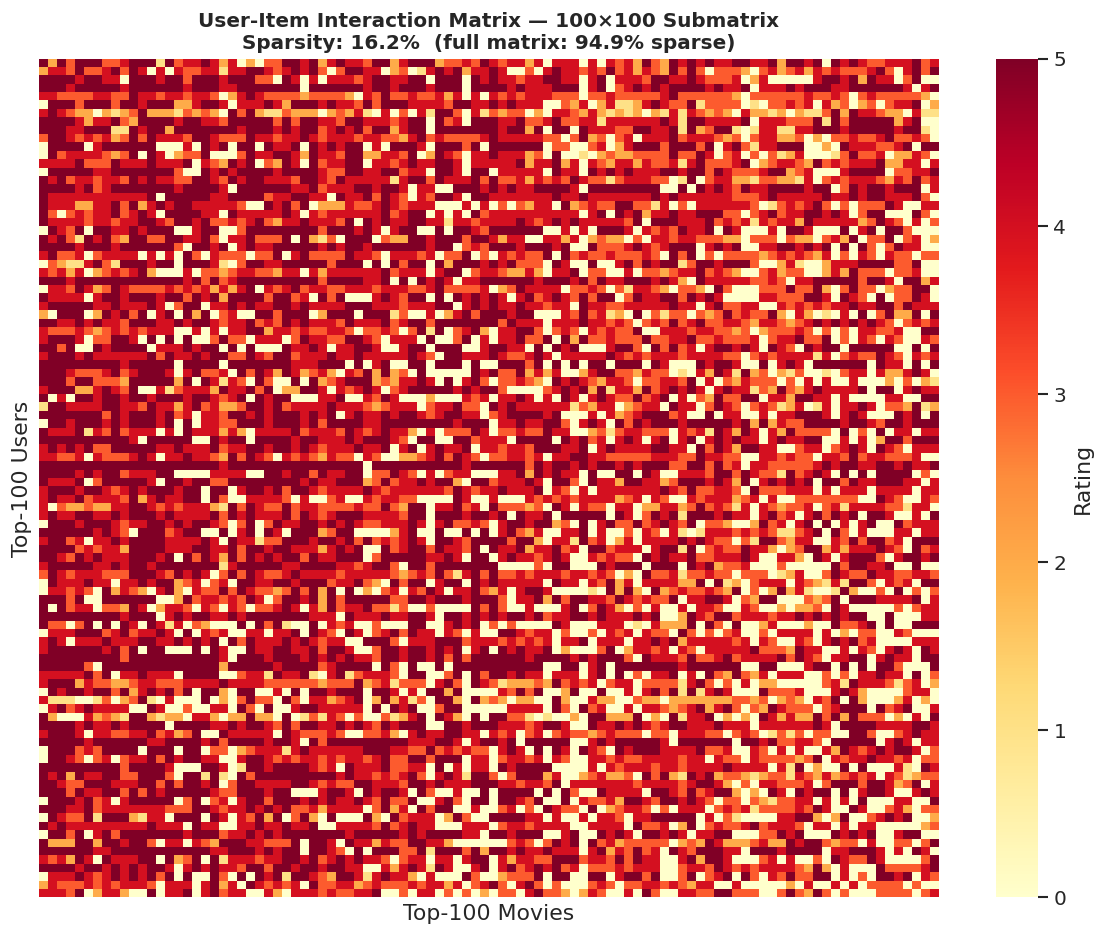

In [ ]:
# Sparsity heatmap (100x100 dense submatrix)
top_users  = train_df.groupby('UserIdx').size().nlargest(100).index.tolist()
top_movies = train_df.groupby('MovieIdx').size().nlargest(100).index.tolist()
sub = train_df[train_df['UserIdx'].isin(top_users) &
               train_df['MovieIdx'].isin(top_movies)].copy()
u_map = {u:i for i,u in enumerate(top_users)}
m_map = {m:i for i,m in enumerate(top_movies)}
mat = np.zeros((100, 100))
for _, row in sub.iterrows():
    mat[u_map[row.UserIdx], m_map[row.MovieIdx]] = row.RatingRaw

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mat, ax=ax, cmap='YlOrRd', cbar_kws={'label':'Rating'},
            xticklabels=False, yticklabels=False)
sparsity = 1 - (mat > 0).sum() / (100*100)
ax.set_title(f'User-Item Interaction Matrix — 100×100 Submatrix\n'
             f'Sparsity: {sparsity:.1%}  (full matrix: {1-len(ratings)/(N_USERS*N_MOVIES):.1%} sparse)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Top-100 Movies'); ax.set_ylabel('Top-100 Users')
plt.tight_layout(); plt.show()

---

## 3. Shared Evaluation Harness

One universal evaluation function — every model calls it, same columns, same logic.

In [ ]:
RELEVANCE_THRESHOLD = 4.0
K = 10
N_EVAL_USERS = 500   # sample for ranking metrics (1M has 6k users, 500 is robust)

# Pre-build lookup dicts once
test_relevant  = (test_df[test_df['RatingRaw'] >= RELEVANCE_THRESHOLD]
                  .groupby('UserID')['MovieID'].apply(set).to_dict())
train_watched  = train_df.groupby('UserID')['MovieID'].apply(set).to_dict()
train_uidx_watched = train_df.groupby('UserIdx')['MovieIdx'].apply(set).to_dict()
test_rel_uidx  = (test_df[test_df['RatingRaw'] >= RELEVANCE_THRESHOLD]
                  .groupby('UserIdx')['MovieIdx'].apply(set).to_dict())

# Training arrays for calibration
TR_UIDX = train_df['UserIdx'].values.astype(int)
TR_MIDX = train_df['MovieIdx'].values.astype(int)
TR_RAT  = train_df['RatingRaw'].values
global_mean = float(train_df['RatingRaw'].mean())

# Results table
results_1m = pd.DataFrame()

def ranking_metrics(score_fn, model_name, mode='userid', k=K, n_sample=N_EVAL_USERS):
    """
    score_fn:
      mode='userid'  -> score_fn(user_id)  -> (N_MOVIES,) array indexed by MovieIdx
      mode='useridx' -> score_fn(user_idx) -> (N_MOVIES,) array indexed by MovieIdx
    Returns dict of ranking metrics.
    """
    if mode == 'userid':
        test_users = test_df['UserID'].unique()
        if len(test_users) > n_sample:
            np.random.seed(RANDOM_STATE)
            test_users = np.random.choice(test_users, n_sample, replace=False)
        precs, recs, ndcgs, hits, rec_items = [], [], [], [], set()
        for uid in test_users:
            uidx    = user2idx.get(uid)
            if uidx is None: continue
            watched = train_watched.get(uid, set())
            rel_mid = test_relevant.get(uid, set())
            if not rel_mid: continue
            rel_idx = {movie2idx[m] for m in rel_mid if m in movie2idx}
            scores  = score_fn(uid).copy().astype(float)
            for m in watched:
                midx = movie2idx.get(m)
                if midx is not None: scores[midx] = -1e9
            top_k = np.argsort(-scores)[:k].tolist()
            rec_items.update(top_k)
            h     = [1 if idx in rel_idx else 0 for idx in top_k]
            nrel  = sum(h)
            precs.append(nrel / k)
            recs.append(nrel / max(len(rel_idx), 1))
            hits.append(1 if nrel > 0 else 0)
            dcg  = sum(hh/log2(i+2) for i,hh in enumerate(h))
            idcg = sum(1/log2(i+2)  for i in range(min(len(rel_idx), k)))
            ndcgs.append(dcg/idcg if idcg > 0 else 0.0)
    else:  # useridx — for DL/GNN
        eligible = list(test_rel_uidx.keys())
        np.random.seed(RANDOM_STATE)
        sampled = np.random.choice(eligible, size=min(n_sample, len(eligible)), replace=False)
        precs, recs, ndcgs, hits, rec_items = [], [], [], [], set()
        for uidx in sampled:
            rel_idx = test_rel_uidx.get(uidx, set())
            if not rel_idx: continue
            watched = train_uidx_watched.get(uidx, set())
            scores  = score_fn(uidx).copy().astype(float)
            for widx in watched:
                if 0 <= widx < len(scores): scores[widx] = -1e9
            top_k = np.argsort(-scores)[:k].tolist()
            rec_items.update(top_k)
            h     = [1 if idx in rel_idx else 0 for idx in top_k]
            nrel  = sum(h)
            precs.append(nrel / k)
            recs.append(nrel / max(len(rel_idx), 1))
            hits.append(1 if nrel > 0 else 0)
            dcg  = sum(hh/log2(i+2) for i,hh in enumerate(h))
            idcg = sum(1/log2(i+2)  for i in range(min(len(rel_idx), k)))
            ndcgs.append(dcg/idcg if idcg > 0 else 0.0)

    return {
        'Precision@10': float(np.mean(precs))  if precs else float('nan'),
        'Recall@10':    float(np.mean(recs))   if recs  else float('nan'),
        'NDCG@10':      float(np.mean(ndcgs))  if ndcgs else float('nan'),
        'HitRate@10':   float(np.mean(hits))   if hits  else float('nan'),
        'Coverage':     len(rec_items) / N_MOVIES,
    }

def calibrate(score_matrix, te_uidx, te_midx):
    """Linear a*score+b calibration on train set, apply to test."""
    tr_sc = score_matrix[TR_UIDX, TR_MIDX].astype(float)
    A     = np.column_stack([tr_sc, np.ones_like(tr_sc)])
    a, b  = np.linalg.lstsq(A, TR_RAT.astype(float), rcond=None)[0]
    te_sc = score_matrix[te_uidx, te_midx].astype(float)
    return pd.Series(np.clip(a*te_sc + b, 1.0, 5.0), index=test_df.index), a, b

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true)-np.array(y_pred))**2)))

def save_result(name, metrics, train_time, rmse_val=float('nan')):
    global results_1m
    row = {'Model': name, 'NDCG@10': metrics['NDCG@10'],
           'Precision@10': metrics['Precision@10'], 'Recall@10': metrics['Recall@10'],
           'HitRate@10': metrics['HitRate@10'], 'Coverage': metrics['Coverage'],
           'RMSE': rmse_val, 'TrainingTime_sec': train_time}
    results_1m = pd.concat([results_1m, pd.DataFrame([row])], ignore_index=True)
    print(f'[{name}] NDCG@10={metrics["NDCG@10"]:.4f}  '
          f'P@10={metrics["Precision@10"]:.4f}  '
          f'Coverage={metrics["Coverage"]:.4f}  '
          f'Time={train_time:.1f}s')

# Val set for early-stopping NDCG
val_rel_uidx  = (val_df[val_df['RatingRaw'] >= RELEVANCE_THRESHOLD]
                 .groupby('UserIdx')['MovieIdx'].apply(set).to_dict())
val_eligible  = list(val_rel_uidx.keys())
np.random.seed(RANDOM_STATE)
val_sample    = np.random.choice(val_eligible, size=min(200, len(val_eligible)), replace=False)

def val_ndcg_score(score_fn_uidx, k=10):
    ndcgs = []
    for uidx in val_sample:
        rel   = val_rel_uidx.get(uidx, set())
        if not rel: continue
        watch = train_uidx_watched.get(uidx, set())
        sc    = score_fn_uidx(uidx).copy().astype(float)
        for w in watch:
            if 0 <= w < len(sc): sc[w] = -1e9
        top_k = np.argsort(-sc)[:k].tolist()
        h     = [1 if i in rel else 0 for i in top_k]
        dcg   = sum(hh/log2(i+2) for i,hh in enumerate(h))
        idcg  = sum(1/log2(i+2)  for i in range(min(len(rel), k)))
        ndcgs.append(dcg/idcg if idcg > 0 else 0.0)
    return float(np.mean(ndcgs)) if ndcgs else 0.0

print('Evaluation harness ready.')
print(f'N_USERS={N_USERS:,}  N_MOVIES={N_MOVIES:,}  global_mean={global_mean:.4f}')

Evaluation harness ready.
N_USERS=6,040  N_MOVIES=3,260  global_mean=3.5914


---

## 4. Model 1 — SVD (TruncatedSVD)

Fastest matrix factorisation. Decomposes the sparse user-item matrix into latent factor matrices P (users) and Q (items). Scores all items via `P @ Q.T`.

In [ ]:
# Build sparse matrix
ui_matrix = csr_matrix(
    (train_df['RatingNorm'].values, (TR_UIDX, TR_MIDX)),
    shape=(N_USERS, N_MOVIES)
)
print(f'Sparse matrix: {ui_matrix.shape}  nnz={ui_matrix.nnz:,}  '
      f'density={ui_matrix.nnz/(N_USERS*N_MOVIES)*100:.3f}%')

# Val NDCG for tuning
def svd_val_ndcg_matrix(S, k=10, n=200):
    eligible = [u for u in val_rel_uidx if u < S.shape[0]]
    np.random.seed(RANDOM_STATE)
    sampled  = np.random.choice(eligible, size=min(n, len(eligible)), replace=False)
    ndcgs = []
    for uidx in sampled:
        rel   = val_rel_uidx.get(uidx, set())
        if not rel: continue
        watch = train_uidx_watched.get(uidx, set())
        sc    = S[uidx].copy()
        for w in watch: sc[w] = -1e9
        top_k = np.argsort(-sc)[:k].tolist()
        h     = [1 if i in rel else 0 for i in top_k]
        dcg   = sum(hh/log2(i+2) for i,hh in enumerate(h))
        idcg  = sum(1/log2(i+2) for i in range(min(len(rel), k)))
        ndcgs.append(dcg/idcg if idcg > 0 else 0.0)
    return float(np.mean(ndcgs)) if ndcgs else 0.0

# Grid search n_components
SVD_GRID = [50, 100, 200]
print('Tuning SVD n_components...')
svd_tune = []
for n_comp in SVD_GRID:
    t0_ = time.perf_counter()
    _svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
    _P   = _svd.fit_transform(ui_matrix)
    _Q   = _svd.components_.T
    _S   = _P @ _Q.T
    _v   = svd_val_ndcg_matrix(_S)
    svd_tune.append({'n_components': n_comp, 'val_NDCG@10': round(_v,4),
                     'time_s': round(time.perf_counter()-t0_,1)})
    print(f'  n={n_comp:3d}  val_NDCG@10={_v:.4f}')

tune_df = pd.DataFrame(svd_tune)
display(tune_df)
svd_best_n = int(tune_df.loc[tune_df['val_NDCG@10'].idxmax(), 'n_components'])
print(f'Best n_components = {svd_best_n}')

Sparse matrix: (6040, 3260)  nnz=798,831  density=4.057%
Tuning SVD n_components...
  n= 50  val_NDCG@10=0.0811
  n=100  val_NDCG@10=0.0652
  n=200  val_NDCG@10=0.0493


,n_components,val_NDCG@10,time_s
0,50,0.0811,0.4000
1,100,0.0652,0.8000
2,200,0.0493,1.4000


Best n_components = 50


In [ ]:
t0 = time.perf_counter()
svd_model  = TruncatedSVD(n_components=svd_best_n, random_state=RANDOM_STATE)
svd_P      = svd_model.fit_transform(ui_matrix)
svd_Q      = svd_model.components_.T
svd_S      = svd_P @ svd_Q.T        # (N_USERS, N_MOVIES)
svd_time   = time.perf_counter() - t0
print(f'SVD trained in {svd_time:.2f}s  |  explained var = {svd_model.explained_variance_ratio_.sum()*100:.1f}%')

# Calibration
svd_preds, svd_a, svd_b = calibrate(svd_S, test_df['UserIdx'].values.astype(int),
                                      test_df['MovieIdx'].values.astype(int))
svd_rmse = rmse(test_df['RatingRaw'], svd_preds)

# Ranking
def svd_score_fn(uid):
    return svd_S[user2idx[uid]]

svd_metrics = ranking_metrics(svd_score_fn, 'SVD', mode='userid')
save_result('SVD', svd_metrics, svd_time, svd_rmse)

SVD trained in 0.42s  |  explained var = 41.2%
[SVD] NDCG@10=0.1681  P@10=0.1503  Coverage=0.1822  Time=0.4s


---

## 5. Model 2 — TF-IDF Content-Based

Bag-of-words over genres + title tokens. Genres are weighted 3× to dominate title noise. Recommends movies similar to what the user has highly rated (≥4 stars).

In [ ]:
# Build text corpus
movies_cb = movies[['MovieID','TitleClean','Genres']].copy().reset_index(drop=True)
movies_cb['genres_text'] = movies_cb['Genres'].str.replace('|',' ',regex=False)\
                                               .str.replace('-',' ',regex=False).str.lower()
movies_cb['title_text']  = movies_cb['TitleClean'].str.lower()\
                                                   .str.replace(r'[^a-z0-9 ]',' ',regex=True)
movies_cb['doc'] = (movies_cb['genres_text'] + ' ') * 3 + movies_cb['title_text']

tfidf_mids   = movies_cb['MovieID'].tolist()
tfidf_mid2i  = {mid: i for i, mid in enumerate(tfidf_mids)}
tfidf_midx   = [movie2idx.get(mid) for mid in tfidf_mids]  # MovieIdx for each position

t0 = time.perf_counter()
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=1, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(movies_cb['doc']).toarray().astype(np.float32)
tfidf_time   = time.perf_counter() - t0
print(f'TF-IDF matrix: {tfidf_matrix.shape}  built in {tfidf_time:.2f}s')

CB_THRESHOLD = 4.0

def tfidf_score_fn(uid):
    """Return (N_MOVIES,) score array indexed by MovieIdx."""
    liked = train_df[(train_df['UserID']==uid) &
                     (train_df['RatingRaw']>=CB_THRESHOLD)]['MovieID'].tolist()
    scores = np.zeros(N_MOVIES, dtype=np.float32)
    if not liked:
        return scores
    idxs    = [tfidf_mid2i[m] for m in liked if m in tfidf_mid2i]
    if not idxs:
        return scores
    profile = tfidf_matrix[idxs].mean(axis=0, keepdims=True)
    norms   = np.linalg.norm(tfidf_matrix, axis=1) + 1e-10
    pnorm   = np.linalg.norm(profile) + 1e-10
    sims    = (tfidf_matrix @ profile.T).flatten() / (norms * pnorm)
    # Map tfidf positions -> MovieIdx positions
    for pos, midx in enumerate(tfidf_midx):
        if midx is not None:
            scores[midx] = sims[pos]
    return scores

tfidf_metrics = ranking_metrics(tfidf_score_fn, 'TF-IDF', mode='userid')
save_result('TF-IDF', tfidf_metrics, tfidf_time)

TF-IDF matrix: (3260, 11822)  built in 0.19s
[TF-IDF] NDCG@10=0.0302  P@10=0.0294  Coverage=0.1509  Time=0.2s


---

## 6. Models 3–5 — Deep Learning (NCF, WideDeep, LightGCN, GraphSAGE)

GPU-accelerated with BPR ranking loss and early stopping on val NDCG@10.

In [ ]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','torch','torch-geometric','-q'],
               capture_output=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import MessagePassing, SAGEConv

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Shared constants
EMB_DIM    = 64
BATCH      = 1024
MAX_EPOCHS = 20
PATIENCE   = 4
LR         = 1e-3

torch.manual_seed(RANDOM_STATE)

# Tensors
tr_u = torch.tensor(TR_UIDX, dtype=torch.long)
tr_i = torch.tensor(TR_MIDX, dtype=torch.long)

# BPR Dataset
class BPRDataset(Dataset):
    def __init__(self, u, i, n_items, watched):
        self.u = u.numpy(); self.i = i.numpy()
        self.n = n_items;   self.w = watched
    def __len__(self): return len(self.u)
    def __getitem__(self, idx):
        u = int(self.u[idx]); i = int(self.i[idx])
        j = np.random.randint(self.n)
        while j in self.w.get(u, set()): j = np.random.randint(self.n)
        return torch.tensor(u), torch.tensor(i), torch.tensor(j)

dl_dataset = BPRDataset(tr_u, tr_i, N_MOVIES, train_uidx_watched)
dl_loader  = DataLoader(dl_dataset, batch_size=BATCH, shuffle=True, num_workers=0)
print(f'BPR DataLoader: {len(dl_dataset):,} samples  {len(dl_loader):,} batches/epoch')

# Generic training loop
def train_bpr(model, score_fn, model_name):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=2, factor=0.5)
    best_val  = -1.0
    best_state= None
    patience_ctr = 0
    t0 = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS+1):
        model.train()
        ep_loss = 0.0
        for u, i_pos, i_neg in dl_loader:
            u, i_pos, i_neg = u.to(DEVICE), i_pos.to(DEVICE), i_neg.to(DEVICE)
            s_pos = model(u, i_pos)
            s_neg = model(u, i_neg)
            loss  = -F.logsigmoid(s_pos - s_neg).mean()
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss += loss.item()
        avg_loss = ep_loss / len(dl_loader)
        vn = val_ndcg_score(score_fn)
        scheduler.step(vn)
        improved = vn > best_val
        if improved:
            best_val   = vn
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        print(f'  [{model_name}] Epoch {epoch:2d}/{MAX_EPOCHS}  '
              f'loss={avg_loss:.4f}  val_NDCG@10={vn:.4f}{" ✓" if improved else ""}')
        if patience_ctr >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break
    model.load_state_dict(best_state)
    return time.perf_counter() - t0, best_val

print('DL setup complete.')

PyTorch 2.10.0+cu128  |  Device: cuda
GPU: Tesla T4
BPR DataLoader: 798,831 samples  781 batches/epoch
DL setup complete.


### NCF — Neural Collaborative Filtering

In [ ]:
class NCF(nn.Module):
    def __init__(self, n_u, n_i, emb=EMB_DIM, hidden=[256,128,64], drop=0.2):
        super().__init__()
        self.ue = nn.Embedding(n_u, emb); self.ie = nn.Embedding(n_i, emb)
        layers  = []
        in_d    = emb * 2
        for h in hidden:
            layers += [nn.Linear(in_d,h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(drop)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.mlp = nn.Sequential(*layers)
        nn.init.normal_(self.ue.weight, std=0.01)
        nn.init.normal_(self.ie.weight, std=0.01)

    def forward(self, u, i):
        return self.mlp(torch.cat([self.ue(u), self.ie(i)], dim=-1)).squeeze(-1)

    def score_all(self, uidx):
        self.eval()
        with torch.no_grad():
            u_vec = self.ue(torch.tensor([uidx], device=DEVICE)).expand(N_MOVIES, -1)
            i_vec = self.ie(torch.arange(N_MOVIES, device=DEVICE))
            return self.mlp(torch.cat([u_vec, i_vec], dim=-1)).squeeze(-1).cpu().numpy()

ncf_model = NCF(N_USERS, N_MOVIES).to(DEVICE)
ncf_score = lambda uidx: ncf_model.score_all(uidx)
ncf_time, ncf_best_val = train_bpr(ncf_model, ncf_score, 'NCF')

ncf_metrics = ranking_metrics(ncf_score, 'NCF', mode='useridx')
save_result('NCF', ncf_metrics, ncf_time)

  [NCF] Epoch  1/20  loss=0.3987  val_NDCG@10=0.2616 ✓
  [NCF] Epoch  2/20  loss=0.3533  val_NDCG@10=0.2709 ✓
  [NCF] Epoch  3/20  loss=0.3160  val_NDCG@10=0.2806 ✓
  [NCF] Epoch  4/20  loss=0.2859  val_NDCG@10=0.2807 ✓
  [NCF] Epoch  5/20  loss=0.2632  val_NDCG@10=0.2688
  [NCF] Epoch  6/20  loss=0.2491  val_NDCG@10=0.2856 ✓
  [NCF] Epoch  7/20  loss=0.2367  val_NDCG@10=0.2799
  [NCF] Epoch  8/20  loss=0.2269  val_NDCG@10=0.2749
  [NCF] Epoch  9/20  loss=0.2187  val_NDCG@10=0.2709
  [NCF] Epoch 10/20  loss=0.2054  val_NDCG@10=0.2970 ✓
  [NCF] Epoch 11/20  loss=0.1982  val_NDCG@10=0.2930
  [NCF] Epoch 12/20  loss=0.1934  val_NDCG@10=0.2807
  [NCF] Epoch 13/20  loss=0.1899  val_NDCG@10=0.2789
  [NCF] Epoch 14/20  loss=0.1827  val_NDCG@10=0.2861
  Early stop at epoch 14
[NCF] NDCG@10=0.1969  P@10=0.1808  Coverage=0.1770  Time=319.5s


### WideDeep — Wide & Deep Learning

In [ ]:
class WideDeep(nn.Module):
    def __init__(self, n_u, n_i, emb=EMB_DIM, hidden=[256,128,64], drop=0.2):
        super().__init__()
        self.wu = nn.Embedding(n_u, 1); self.wi = nn.Embedding(n_i, 1)
        self.wb = nn.Parameter(torch.zeros(1))
        self.ue = nn.Embedding(n_u, emb); self.ie = nn.Embedding(n_i, emb)
        layers  = []
        in_d    = emb * 2
        for h in hidden:
            layers += [nn.Linear(in_d,h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(drop)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.deep = nn.Sequential(*layers)
        for emb_layer in [self.ue, self.ie]:
            nn.init.normal_(emb_layer.weight, std=0.01)
        nn.init.zeros_(self.wu.weight); nn.init.zeros_(self.wi.weight)

    def forward(self, u, i):
        wide = self.wu(u) + self.wi(i) + self.wb
        deep = self.deep(torch.cat([self.ue(u), self.ie(i)], dim=-1))
        return (wide + deep).squeeze(-1)

    def score_all(self, uidx):
        self.eval()
        with torch.no_grad():
            all_i = torch.arange(N_MOVIES, device=DEVICE)
            u_t   = torch.tensor([uidx], device=DEVICE).expand(N_MOVIES)
            wide  = self.wu(u_t) + self.wi(all_i) + self.wb
            deep  = self.deep(torch.cat([self.ue(u_t), self.ie(all_i)], dim=-1))
            return (wide + deep).squeeze(-1).cpu().numpy()

wd_model = WideDeep(N_USERS, N_MOVIES).to(DEVICE)
wd_score = lambda uidx: wd_model.score_all(uidx)
wd_time, wd_best_val = train_bpr(wd_model, wd_score, 'WideDeep')

wd_metrics = ranking_metrics(wd_score, 'WideDeep', mode='useridx')
save_result('WideDeep', wd_metrics, wd_time)

  [WideDeep] Epoch  1/20  loss=0.3978  val_NDCG@10=0.2640 ✓
  [WideDeep] Epoch  2/20  loss=0.3538  val_NDCG@10=0.2686 ✓
  [WideDeep] Epoch  3/20  loss=0.3113  val_NDCG@10=0.2714 ✓
  [WideDeep] Epoch  4/20  loss=0.2846  val_NDCG@10=0.2737 ✓
  [WideDeep] Epoch  5/20  loss=0.2635  val_NDCG@10=0.2679
  [WideDeep] Epoch  6/20  loss=0.2493  val_NDCG@10=0.2777 ✓
  [WideDeep] Epoch  7/20  loss=0.2379  val_NDCG@10=0.2747
  [WideDeep] Epoch  8/20  loss=0.2279  val_NDCG@10=0.2791 ✓
  [WideDeep] Epoch  9/20  loss=0.2199  val_NDCG@10=0.2837 ✓
  [WideDeep] Epoch 10/20  loss=0.2137  val_NDCG@10=0.2831
  [WideDeep] Epoch 11/20  loss=0.2077  val_NDCG@10=0.2834
  [WideDeep] Epoch 12/20  loss=0.2046  val_NDCG@10=0.2823
  [WideDeep] Epoch 13/20  loss=0.1913  val_NDCG@10=0.3034 ✓
  [WideDeep] Epoch 14/20  loss=0.1840  val_NDCG@10=0.2895
  [WideDeep] Epoch 15/20  loss=0.1824  val_NDCG@10=0.2894
  [WideDeep] Epoch 16/20  loss=0.1794  val_NDCG@10=0.2903
  [WideDeep] Epoch 17/20  loss=0.1734  val_NDCG@10=0.292

### GNN Setup — Bipartite Edge Index

In [ ]:
GNN_N_NODES = N_USERS + N_MOVIES
GNN_REG     = 1e-4
GNN_BATCH   = 4096

src_u = torch.tensor(TR_UIDX, dtype=torch.long)
src_i = torch.tensor(TR_MIDX + N_USERS, dtype=torch.long)
gnn_edge_index = torch.stack([
    torch.cat([src_u, src_i]),
    torch.cat([src_i, src_u]),
], dim=0).to(DEVICE)

deg = torch.zeros(GNN_N_NODES, device=DEVICE)
deg.scatter_add_(0, gnn_edge_index[0],
                 torch.ones(gnn_edge_index.size(1), device=DEVICE))
gnn_norm = (1.0 / (deg[gnn_edge_index[0]] * deg[gnn_edge_index[1]])
            .sqrt().clamp(min=1e-8))

gnn_u = torch.tensor(TR_UIDX, dtype=torch.long)
gnn_i = torch.tensor(TR_MIDX + N_USERS, dtype=torch.long)
gnn_n = len(gnn_u)

def gnn_train(model, emb_fn, model_name):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    best_val  = -1.0; best_state = None; patience_ctr = 0
    t0 = time.perf_counter()

    def score_fn(uidx):
        model.eval()
        with torch.no_grad():
            embs   = emb_fn()
            u_emb  = embs[uidx].unsqueeze(0)
            i_embs = embs[N_USERS:]
            return (u_emb @ i_embs.T).squeeze(0).cpu().numpy()

    for epoch in range(1, MAX_EPOCHS+1):
        model.train()
        perm = torch.randperm(gnn_n)
        ep_loss = 0.0; n_steps = 0
        for start in range(0, gnn_n, GNN_BATCH):
            idx   = perm[start:start+GNN_BATCH]
            u_b   = gnn_u[idx].to(DEVICE)
            ip_b  = gnn_i[idx].to(DEVICE)
            ig_b  = torch.randint(N_USERS, GNN_N_NODES, (len(u_b),), device=DEVICE)
            embs  = emb_fn()
            eu    = embs[u_b]; eip = embs[ip_b]; eig = embs[ig_b]
            diff  = (eu*eip).sum(-1) - (eu*eig).sum(-1)
            bpr   = -F.logsigmoid(diff).mean()
            reg   = GNN_REG * (eu.norm(2).pow(2)+eip.norm(2).pow(2)+eig.norm(2).pow(2)) / len(u_b)
            loss  = bpr + reg
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss += loss.item(); n_steps += 1
        avg_loss = ep_loss / n_steps
        vn = val_ndcg_score(score_fn)
        improved = vn > best_val
        if improved:
            best_val = vn
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        print(f'  [{model_name}] Epoch {epoch:2d}/{MAX_EPOCHS}  '
              f'loss={avg_loss:.4f}  val_NDCG@10={vn:.4f}{" ✓" if improved else ""}')
        if patience_ctr >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break
    model.load_state_dict(best_state)
    return time.perf_counter() - t0, score_fn

print(f'GNN setup: {GNN_N_NODES:,} nodes  {gnn_edge_index.shape[1]:,} edges')

GNN setup: 9,300 nodes  1,597,662 edges


### LightGCN

In [ ]:
class LightGCNConv(MessagePassing):
    def __init__(self): super().__init__(aggr='add')
    def forward(self, x, edge_index, norm):
        return self.propagate(edge_index, x=x, norm=norm)
    def message(self, x_j, norm): return norm.view(-1,1) * x_j

class LightGCN(nn.Module):
    def __init__(self, n_nodes, emb=EMB_DIM, n_layers=3):
        super().__init__()
        self.emb   = nn.Embedding(n_nodes, emb)
        self.convs = nn.ModuleList([LightGCNConv() for _ in range(n_layers)])
        nn.init.xavier_uniform_(self.emb.weight)
    def get_embeddings(self):
        x = self.emb.weight; out = [x]
        for conv in self.convs:
            x = conv(x, gnn_edge_index, gnn_norm); out.append(x)
        return torch.stack(out, dim=0).mean(dim=0)

lgcn_model = LightGCN(GNN_N_NODES).to(DEVICE)
lgcn_time, lgcn_score = gnn_train(lgcn_model, lgcn_model.get_embeddings, 'LightGCN')
lgcn_metrics = ranking_metrics(lgcn_score, 'LightGCN', mode='useridx')
save_result('LightGCN', lgcn_metrics, lgcn_time)

  [LightGCN] Epoch  1/20  loss=0.5638  val_NDCG@10=0.1729 ✓
  [LightGCN] Epoch  2/20  loss=0.4548  val_NDCG@10=0.1698
  [LightGCN] Epoch  3/20  loss=0.4461  val_NDCG@10=0.1698
  [LightGCN] Epoch  4/20  loss=0.4387  val_NDCG@10=0.1690
  [LightGCN] Epoch  5/20  loss=0.4347  val_NDCG@10=0.1701
  Early stop at epoch 5
[LightGCN] NDCG@10=0.1842  P@10=0.1726  Coverage=0.0589  Time=92.7s


### GraphSAGE

In [ ]:
class GraphSAGERec(nn.Module):
    def __init__(self, n_nodes, emb=EMB_DIM, n_layers=2):
        super().__init__()
        self.emb     = nn.Embedding(n_nodes, emb)
        self.convs   = nn.ModuleList([SAGEConv(emb, emb, normalize=True) for _ in range(n_layers)])
        self.dropout = nn.Dropout(0.1)
        nn.init.xavier_uniform_(self.emb.weight)
    def get_embeddings(self):
        x = self.emb.weight
        for i, conv in enumerate(self.convs):
            x = conv(x, gnn_edge_index)
            if i < len(self.convs)-1: x = F.relu(x); x = self.dropout(x)
        return x

sage_model = GraphSAGERec(GNN_N_NODES).to(DEVICE)
sage_time, sage_score = gnn_train(sage_model, sage_model.get_embeddings, 'GraphSAGE')
sage_metrics = ranking_metrics(sage_score, 'GraphSAGE', mode='useridx')
save_result('GraphSAGE', sage_metrics, sage_time)

  [GraphSAGE] Epoch  1/20  loss=0.5023  val_NDCG@10=0.0665 ✓
  [GraphSAGE] Epoch  2/20  loss=0.4669  val_NDCG@10=0.0639
  [GraphSAGE] Epoch  3/20  loss=0.4563  val_NDCG@10=0.0661
  [GraphSAGE] Epoch  4/20  loss=0.4446  val_NDCG@10=0.0530
  [GraphSAGE] Epoch  5/20  loss=0.4406  val_NDCG@10=0.0619
  Early stop at epoch 5
[GraphSAGE] NDCG@10=0.0981  P@10=0.0980  Coverage=0.1227  Time=43.2s


---

## 7. 1M Leaderboard & Comparison with 100K

In [ ]:
# Style and display final results
res = results_1m.sort_values('NDCG@10', ascending=False).reset_index(drop=True)
res.index += 1

num_cols = ['NDCG@10','Precision@10','Recall@10','HitRate@10','Coverage','RMSE','TrainingTime_sec']
display(
    res.style
    .format({c: '{:.4f}' for c in num_cols}, na_rep='—')
    .background_gradient(cmap='RdYlGn', subset=['NDCG@10'],       axis=0)
    .background_gradient(cmap='RdYlGn', subset=['Precision@10'],  axis=0)
    .background_gradient(cmap='RdYlGn', subset=['Coverage'],      axis=0)
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE'],        axis=0)
    .set_caption('MovieLens 1M — Winner Validation Leaderboard')
)
winner_1m = res.iloc[0]['Model']
print(f'\n1M Winner: {winner_1m}  (NDCG@10={res.iloc[0]["NDCG@10"]:.4f})')

,Model,NDCG@10,Precision@10,Recall@10,HitRate@10,Coverage,RMSE,TrainingTime_sec
1,WideDeep,0.2008,0.1776,0.0504,0.6260,0.1939,—,382.3085
2,NCF,0.1969,0.1808,0.0507,0.6240,0.1770,—,319.5453
3,LightGCN,0.1842,0.1726,0.0425,0.5800,0.0589,—,92.7091
4,SVD,0.1681,0.1503,0.0486,0.5501,0.1822,1.1536,0.4222
5,GraphSAGE,0.0981,0.0980,0.0241,0.4300,0.1227,—,43.1983
6,TF-IDF,0.0302,0.0294,0.0060,0.1800,0.1509,—,0.1942



1M Winner: WideDeep  (NDCG@10=0.2008)


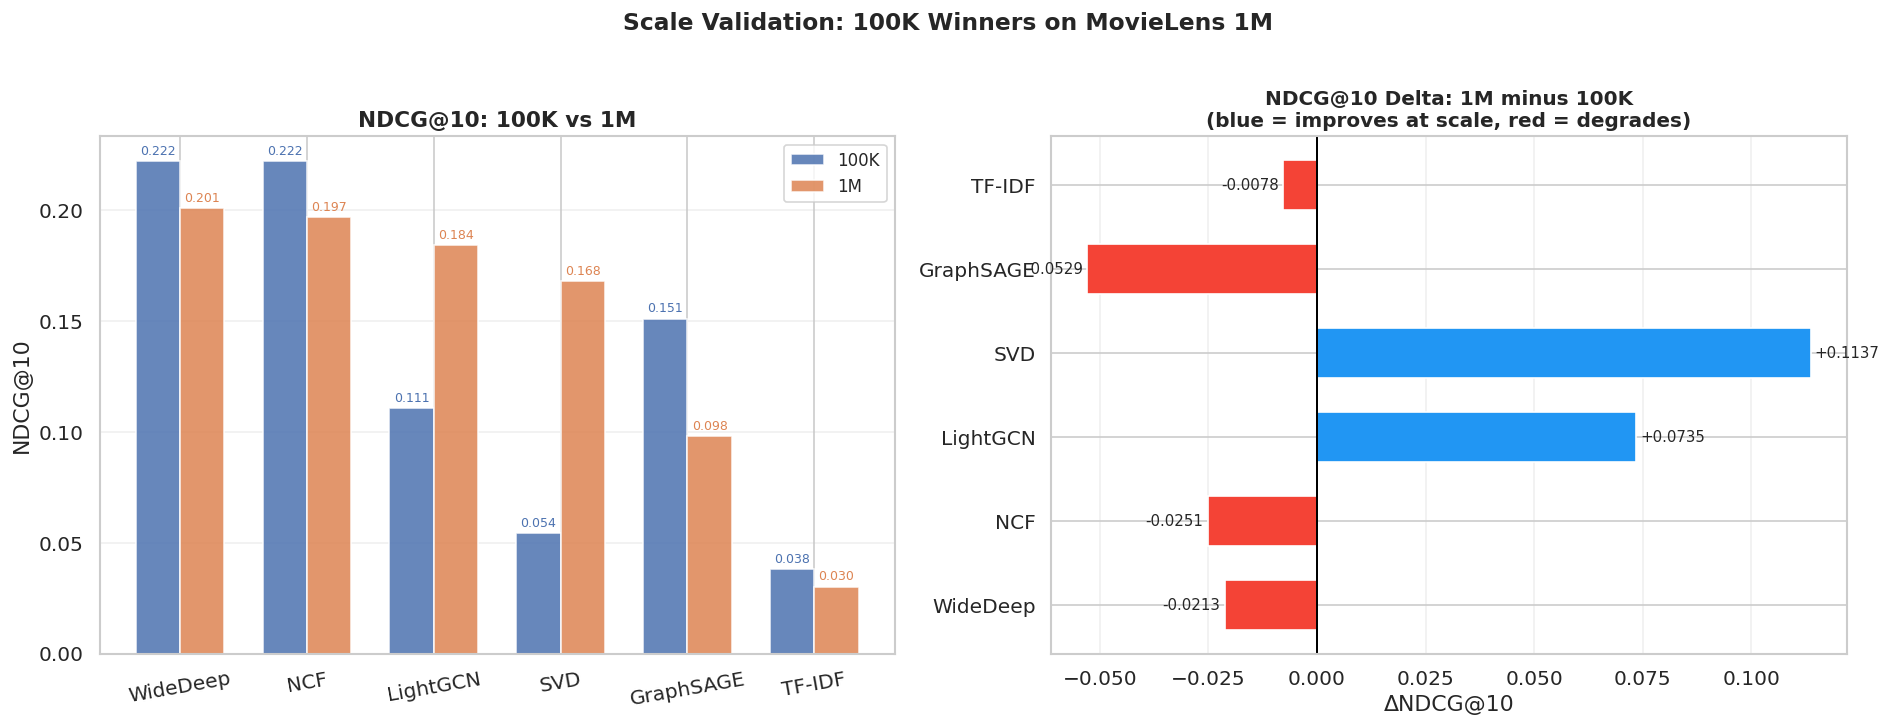

,Model,NDCG@10_100K,NDCG@10,NDCG_delta
0,WideDeep,0.2221,0.2008,-0.0213
1,NCF,0.2220,0.1969,-0.0251
2,LightGCN,0.1107,0.1842,0.0735
3,SVD,0.0544,0.1681,0.1137
4,GraphSAGE,0.1510,0.0981,-0.0529
5,TF-IDF,0.0380,0.0302,-0.0078


In [ ]:
# 100K results for comparison (from the comparative study)
results_100k = pd.DataFrame([
    {'Model':'SVD',       'NDCG@10_100K':0.0544, 'P@10_100K':0.0447},
    {'Model':'TF-IDF',    'NDCG@10_100K':0.0380, 'P@10_100K':0.0304},
    {'Model':'NCF',       'NDCG@10_100K':0.2220, 'P@10_100K':0.2013},
    {'Model':'WideDeep',  'NDCG@10_100K':0.2221, 'P@10_100K':0.2026},
    {'Model':'LightGCN',  'NDCG@10_100K':0.1107, 'P@10_100K':0.1079},
    {'Model':'GraphSAGE', 'NDCG@10_100K':0.1510, 'P@10_100K':0.1408},
])

comp = res[['Model','NDCG@10','Precision@10']].merge(results_100k, on='Model')
comp['NDCG_delta'] = comp['NDCG@10'] - comp['NDCG@10_100K']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NDCG@10 grouped bar: 100K vs 1M
ax = axes[0]
x  = np.arange(len(comp))
w  = 0.35
colors = ['#4C72B0','#DD8452']
ax.bar(x-w/2, comp['NDCG@10_100K'], w, label='100K', color=colors[0], alpha=0.85, edgecolor='white')
ax.bar(x+w/2, comp['NDCG@10'],      w, label='1M',   color=colors[1], alpha=0.85, edgecolor='white')
for i, (v100, v1m) in enumerate(zip(comp['NDCG@10_100K'], comp['NDCG@10'])):
    ax.text(i-w/2, v100+0.003, f'{v100:.3f}', ha='center', fontsize=7.5, color=colors[0])
    ax.text(i+w/2, v1m+0.003,  f'{v1m:.3f}',  ha='center', fontsize=7.5, color=colors[1])
ax.set_xticks(x); ax.set_xticklabels(comp['Model'], rotation=10)
ax.set_title('NDCG@10: 100K vs 1M', fontsize=13, fontweight='bold')
ax.set_ylabel('NDCG@10'); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# Delta chart
ax2 = axes[1]
bar_colors = ['#2196F3' if v >= 0 else '#F44336' for v in comp['NDCG_delta']]
bars = ax2.barh(comp['Model'], comp['NDCG_delta'], color=bar_colors,
                edgecolor='white', height=0.6)
for bar, v in zip(bars, comp['NDCG_delta']):
    ax2.text(v + 0.001 if v >= 0 else v - 0.001,
             bar.get_y()+bar.get_height()/2,
             f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax2.axvline(0, color='black', linewidth=1.2)
ax2.set_title('NDCG@10 Delta: 1M minus 100K\n(blue = improves at scale, red = degrades)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('ΔNDCG@10'); ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Scale Validation: 100K Winners on MovieLens 1M',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

display(comp[['Model','NDCG@10_100K','NDCG@10','NDCG_delta']].round(4))

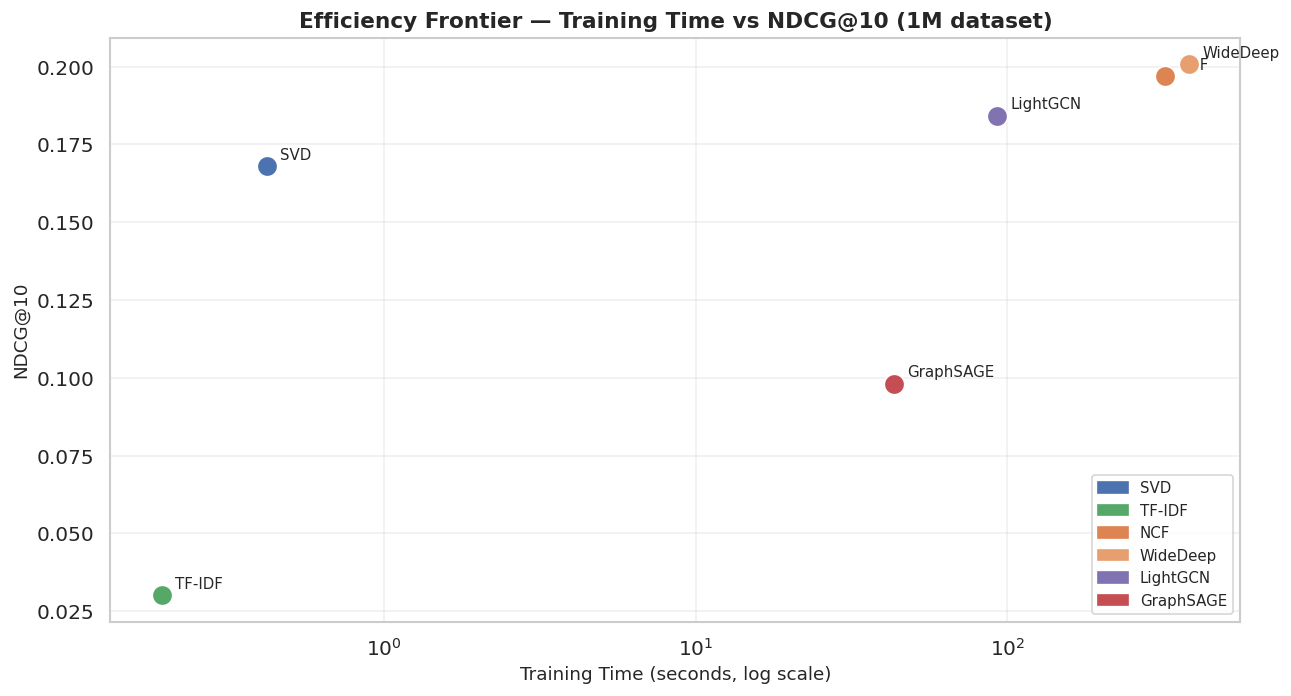

In [ ]:
# Efficiency frontier: Training Time vs NDCG@10
FAMILY_PAL = {
    'SVD':'#4C72B0', 'TF-IDF':'#55A868',
    'NCF':'#DD8452', 'WideDeep':'#E89F70',
    'LightGCN':'#8172B2', 'GraphSAGE':'#C44E52',
}

fig, ax = plt.subplots(figsize=(11, 6))
for _, row in res.iterrows():
    color = FAMILY_PAL.get(row['Model'], '#888')
    ax.scatter(row['TrainingTime_sec'], row['NDCG@10'],
               color=color, s=150, zorder=4, edgecolors='white', linewidth=1)
    ax.annotate(row['Model'], (row['TrainingTime_sec'], row['NDCG@10']),
                xytext=(8,4), textcoords='offset points', fontsize=9)

ax.set_xscale('log')
ax.set_title('Efficiency Frontier — Training Time vs NDCG@10 (1M dataset)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Time (seconds, log scale)', fontsize=11)
ax.set_ylabel('NDCG@10', fontsize=11)
ax.grid(alpha=0.3)
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in FAMILY_PAL.items()]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

---

## 8. Existing User Recommender

For any UserID in the dataset:
- **< 20 training ratings** → cold-start mode using TF-IDF content-based similarity
- **≥ 20 training ratings** → warm mode using SVD fold-in (personalised latent vector computed from training ratings, updated in ~10ms)

SVD fold-in solves `p @ Q.T ≈ r` via least squares for the new user vector — exact personalisation without full retraining.

In [ ]:
# ── Movie metadata lookups ────────────────────────────────────────────────────
midx_to_title = {}
midx_to_genre = {}
midx_to_year  = {}
midx_to_mid   = {}
for _, row in movies.iterrows():
    mid = row['MovieID']
    if mid in movie2idx:
        midx = movie2idx[mid]
        midx_to_title[midx] = row['TitleClean']
        midx_to_genre[midx] = row['Genres']
        midx_to_year[midx]  = int(row['Year']) if pd.notna(row.get('Year')) else '?'
        midx_to_mid[midx]   = mid

COLD_THRESHOLD = 20   # switch to warm mode above this

# ── SVD fold-in: compute personalised vector for any user ─────────────────────
def svd_fold_in(rated_midxs, rated_values):
    """
    Given list of (movie_idx, rating_raw) pairs, solve for user latent vector
    p such that p @ Q.T ≈ ratings.  Returns (N_MOVIES,) score array.
    """
    if not rated_midxs:
        return np.zeros(N_MOVIES)
    Q_sub = svd_Q[rated_midxs, :]          # (n_rated, n_factors)
    r_sub = np.array(rated_values, dtype=float)
    # Least squares: min ||Q_sub @ p - r_sub||
    p_new, _, _, _ = np.linalg.lstsq(Q_sub, r_sub, rcond=None)
    return svd_S.mean(axis=0) + p_new @ svd_Q.T   # global mean offset + personalised

# ── TF-IDF cold-start: profile from liked movie indices ───────────────────────
def tfidf_cold_scores(liked_midxs):
    """Build TF-IDF profile from liked MovieIdx list. Returns (N_MOVIES,) scores."""
    scores = np.zeros(N_MOVIES, dtype=np.float32)
    if not liked_midxs:
        return scores
    # Convert MovieIdx -> TF-IDF matrix row
    tfidf_rows = []
    for midx in liked_midxs:
        mid = midx_to_mid.get(midx)
        if mid and mid in tfidf_mid2i:
            tfidf_rows.append(tfidf_mid2i[mid])
    if not tfidf_rows:
        return scores
    profile = tfidf_matrix[tfidf_rows].mean(axis=0, keepdims=True)
    norms   = np.linalg.norm(tfidf_matrix, axis=1) + 1e-10
    pnorm   = np.linalg.norm(profile) + 1e-10
    sims    = (tfidf_matrix @ profile.T).flatten() / (norms * pnorm)
    for pos, midx in enumerate(tfidf_midx):
        if midx is not None:
            scores[midx] = sims[pos]
    return scores

# ── Core recommend function: auto-selects cold vs warm ───────────────────────
def recommend_for_user(user_id, n=10):
    """
    Smart recommender for any existing user.
    Returns (recs, mode) where mode is 'cold' or 'warm'.
    """
    uid_ratings = train_df[train_df['UserID'] == user_id]
    n_ratings   = len(uid_ratings)
    watched_midxs = set(uid_ratings['MovieIdx'].values.astype(int))

    if n_ratings < COLD_THRESHOLD:
        # Cold-start: TF-IDF on liked movies
        liked_midxs = uid_ratings[uid_ratings['RatingRaw'] >= 4.0]['MovieIdx'].values.astype(int).tolist()
        if not liked_midxs:
            liked_midxs = uid_ratings['MovieIdx'].values.astype(int).tolist()  # fallback: all rated
        scores = tfidf_cold_scores(liked_midxs).astype(float)
        mode   = 'cold'
    else:
        # Warm: SVD fold-in
        rated_midxs  = uid_ratings['MovieIdx'].values.astype(int).tolist()
        rated_values = uid_ratings['RatingRaw'].values.tolist()
        scores = svd_fold_in(rated_midxs, rated_values).astype(float)
        mode   = 'warm'

    # Mask watched
    for midx in watched_midxs:
        if 0 <= midx < N_MOVIES: scores[midx] = -1e9

    top_k = np.argsort(-scores)[:n]
    recs  = [{'rank': i+1,
               'title':  midx_to_title.get(midx, '?'),
               'year':   midx_to_year.get(midx, '?'),
               'genres': midx_to_genre.get(midx, '?'),
               'score':  float(scores[midx])}
              for i, midx in enumerate(top_k)]
    return recs, mode, n_ratings

def user_profile(user_id):
    udf = train_df[train_df['UserID'] == user_id]
    if udf.empty:
        return None
    top_genres = (udf.assign(Genre=udf['Genres'].str.split('|'))
                     .explode('Genre')
                     .groupby('Genre').size()
                     .sort_values(ascending=False)
                     .head(3).index.tolist())
    top_rated  = (udf[udf['RatingRaw'] >= 4.0]
                    .nlargest(3, 'RatingRaw')[['TitleClean','RatingRaw']])
    return {'n_ratings':   len(udf),
            'mean_rating': udf['RatingRaw'].mean(),
            'top_genres':  ', '.join(top_genres),
            'top_rated':   top_rated}

print('Hybrid recommender ready.')
print(f'Cold-start threshold : {COLD_THRESHOLD} ratings')
print(f'Warm model           : SVD fold-in  (n_factors={svd_best_n})')


Hybrid recommender ready.
Cold-start threshold : 20 ratings
Warm model           : SVD fold-in  (n_factors=50)


In [ ]:
BORDER = '=' * 62
THIN   = '-' * 62
MODE_TAG = {'cold': '❄️  COLD-START  (TF-IDF)', 'warm': '🔥  WARM  (SVD fold-in)'}

def print_user_recs(user_id, n=10):
    # Accept any UserID — cold start handles sparse users
    uid_in_train = user_id in set(train_df['UserID'].values)
    if not uid_in_train:
        print(f'  UserID {user_id} not found in the 1M dataset (valid range: '              f'{min(train_df["UserID"]):,} – {max(train_df["UserID"]):,})')
        return

    profile          = user_profile(user_id)
    recs, mode, n_rt = recommend_for_user(user_id, n=n)

    print(BORDER)
    print(f'  User {user_id}  |  {MODE_TAG[mode]}')
    print(THIN)
    print(f'  Training ratings : {n_rt}  '          f'({"below" if n_rt < COLD_THRESHOLD else "above"} '          f'{COLD_THRESHOLD}-rating threshold)')
    if profile:
        print(f'  Mean rating      : {profile["mean_rating"]:.2f} / 5.0')
        print(f'  Top genres       : {profile["top_genres"]}')
        if not profile["top_rated"].empty:
            print('  Top rated        : ' +
                  ', '.join(f'{r["TitleClean"]} ({r["RatingRaw"]:.0f}★)'
                             for _, r in profile["top_rated"].iterrows()))
    print(THIN)
    print(f'  Top {n} Recommendations')
    print(THIN)
    for rec in recs:
        g = rec['genres'].replace('|', ' · ')[:38]
        print(f'  {rec["rank"]:2d}. {rec["title"][:38]:38s}  ({rec["year"]})  {g}')
    print(BORDER)

# ── Run loop ──────────────────────────────────────────────────────────────────
all_uids = sorted(train_df['UserID'].unique())
print(f'UserIDs available: {all_uids[0]:,} – {all_uids[-1]:,}  ({len(all_uids):,} users)')
print(f'Users with < {COLD_THRESHOLD} ratings (cold-start): '      f'{sum(1 for u in all_uids if len(train_df[train_df["UserID"]==u]) < COLD_THRESHOLD):,}')
print('\nEnter any UserID. Type "q" to quit.\n')

while True:
    try:
        raw = input('Enter UserID: ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\nSession ended.'); break
    if raw.lower() in ('q', 'quit', 'exit'):
        print('Session ended.'); break
    try:
        uid = int(raw)
    except ValueError:
        print(f'  Invalid input — enter a numeric UserID or "q" to quit.')
        continue
    print()
    print_user_recs(uid, n=10)
    print()


UserIDs available: 636 – 6,040  (5,399 users)
Users with < 20 ratings (cold-start): 106

Enter any UserID. Type "q" to quit.


  User 650  |  🔥  WARM  (SVD fold-in)
--------------------------------------------------------------
  Training ratings : 28  (above 20-rating threshold)
  Mean rating      : 3.96 / 5.0
  Top genres       : Action, Comedy, Thriller
  Top rated        : Sixteen Candles (5★), One Flew Over the Cuckoo's Nest (5★), Matrix, The (5★)
--------------------------------------------------------------
  Top 10 Recommendations
--------------------------------------------------------------
   1. Lethal Weapon                           (1987)  Action · Comedy · Crime · Drama
   2. Get Shorty                              (1995)  Action · Comedy · Drama
   3. Army of Darkness                        (1993)  Action · Adventure · Comedy · Horror ·
   4. Romancing the Stone                     (1984)  Action · Adventure · Comedy · Romance
   5. Lethal Weapon 2                      

---

## 9. New-User Real-Time Recommender

No UserID needed. You rate movies one by one and recommendations update after every rating.

- **< 20 ratings** — TF-IDF cold-start. Profile = mean of liked movie TF-IDF vectors. Updates instantly.
- **≥ 20 ratings** — SVD fold-in. Your latent taste vector is recomputed from all your ratings in ~10ms. Recommendations shift to the personalised embedding space.

The session starts with 10 popular seed movies to get an initial read on your taste, then enters the interactive rating loop.

In [ ]:
# ── Seed pool: popular movies spanning multiple genres ────────────────────────
popular_by_genre = {}
genre_counts_all = (movies.assign(Genre=movies['Genres'].str.split('|'))
                           .explode('Genre')
                           .groupby('Genre'))
rating_counts = train_df.groupby('MovieID').size().rename('n_ratings')

for genre, grp in genre_counts_all:
    genre_mids = grp['MovieID'].tolist()
    top = (rating_counts[rating_counts.index.isin(genre_mids)]
           .nlargest(3).index.tolist())
    popular_by_genre[genre] = top

# Build diverse seed pool: top-1 from each major genre, deduped
MAJOR_GENRES = ['Action','Adventure','Animation','Comedy','Crime',
                'Drama','Horror','Romance','Sci-Fi','Thriller']
seed_pool = []
seen_seed = set()
for g in MAJOR_GENRES:
    for mid in popular_by_genre.get(g, []):
        if mid not in seen_seed and mid in movie2idx:
            seed_pool.append(mid)
            seen_seed.add(mid)
            break

def fmt_movie(mid, idx=None):
    midx  = movie2idx.get(mid)
    title = midx_to_title.get(midx, '?')
    year  = midx_to_year.get(midx, '?')
    genre = midx_to_genre.get(midx, '?').replace('|', ' · ')[:35]
    prefix = f'{idx:2d}. ' if idx is not None else '    '
    return f'{prefix}{title[:38]:38s}  ({year})  {genre}'

def get_recs_realtime(user_ratings, n=10):
    """
    user_ratings: list of (movie_id, rating_raw) tuples
    Returns (recs, mode)
    """
    watched_mids = {mid for mid, _ in user_ratings}
    watched_midxs = {movie2idx[mid] for mid in watched_mids if mid in movie2idx}
    n_rated = len(user_ratings)

    if n_rated < COLD_THRESHOLD:
        liked_midxs = [movie2idx[mid] for mid, r in user_ratings
                       if r >= 4.0 and mid in movie2idx]
        if not liked_midxs:
            liked_midxs = [movie2idx[mid] for mid, _ in user_ratings if mid in movie2idx]
        scores = tfidf_cold_scores(liked_midxs).astype(float)
        mode   = 'cold'
    else:
        rated_midxs  = [movie2idx[mid] for mid, _ in user_ratings if mid in movie2idx]
        rated_values = [r for mid, r in user_ratings if mid in movie2idx]
        scores = svd_fold_in(rated_midxs, rated_values).astype(float)
        mode   = 'warm'

    for midx in watched_midxs:
        if 0 <= midx < N_MOVIES: scores[midx] = -1e9

    top_k = np.argsort(-scores)[:n]
    recs  = [{'rank': i+1, 'mid': midx_to_mid.get(midx),
               'title': midx_to_title.get(midx, '?'),
               'year':  midx_to_year.get(midx, '?'),
               'genres': midx_to_genre.get(midx, '?'),
               'score':  float(scores[midx])}
              for i, midx in enumerate(top_k)]
    return recs, mode

def run_realtime_recommender():
    user_ratings = []   # list of (movie_id, rating_raw)
    BORDER_ = '=' * 62
    THIN_   = '-' * 62

    print(BORDER_)
    print('  MovieLens 1M — New User Recommender')
    print('  Rate movies as you go. Recommendations update live.')
    print('  Commands: enter 1-5 to rate · "s" to skip · "q" to quit')
    print(BORDER_)
    print()

    # ── Phase 1: seed ratings ─────────────────────────────────────────────────
    print('  Let\'s start with some popular movies.')
    print('  Rate any you\'ve seen, skip the rest.\n')

    for i, mid in enumerate(seed_pool[:10], 1):
        print('  ' + fmt_movie(mid, i))

    print()
    rated_seeds = False
    for i, mid in enumerate(seed_pool[:10], 1):
        midx  = movie2idx.get(mid)
        title = midx_to_title.get(midx, '?')
        while True:
            try:
                raw = input(f'  Rate "{title[:30]}" (1-5 or s to skip): ').strip().lower()
            except (EOFError, KeyboardInterrupt):
                print('\nSession ended.'); return
            if raw == 'q':
                print('Session ended.'); return
            if raw == 's' or raw == '':
                break
            try:
                r = int(raw)
                if 1 <= r <= 5:
                    user_ratings.append((mid, float(r)))
                    rated_seeds = True
                    break
                else:
                    print('  Please enter a number 1-5.')
            except ValueError:
                print('  Please enter a number 1-5 or "s" to skip.')

    if not user_ratings:
        print('\n  No ratings given — please rate at least one movie to get started.')
        return

    # ── Phase 2: interactive rating loop ─────────────────────────────────────
    print()
    while True:
        n_rated = len(user_ratings)
        recs, mode = get_recs_realtime(user_ratings, n=10)

        # Header
        print(BORDER_)
        if mode == 'cold':
            remaining = COLD_THRESHOLD - n_rated
            print(f'  ❄️  COLD-START  |  {n_rated} ratings  |  '                  f'{remaining} more until personalised mode')
        else:
            print(f'  🔥  PERSONALISED  |  {n_rated} ratings  |  SVD fold-in')
        print(THIN_)
        print(f'  Your top 10 recommendations:')
        print(THIN_)
        for rec in recs:
            g = rec['genres'].replace('|', ' · ')[:35]
            print(f'  {rec["rank"]:2d}. {rec["title"][:38]:38s}  ({rec["year"]})  {g}')
        print(BORDER_)
        print()
        print('  Enter the rank (1-10) of a movie to rate it,')
        print('  or press Enter to refresh recommendations.')
        print()

        # Get input
        while True:
            try:
                raw = input('  Your choice: ').strip().lower()
            except (EOFError, KeyboardInterrupt):
                print('\nSession ended.'); return
            if raw == 'q':
                print(BORDER_)
                print(f'  Session complete.  Total ratings: {len(user_ratings)}')
                genre_tally = {}
                for mid, r in user_ratings:
                    if r >= 4.0:
                        midx = movie2idx.get(mid)
                        for g in midx_to_genre.get(midx,'').split('|'):
                            genre_tally[g] = genre_tally.get(g, 0) + 1
                if genre_tally:
                    top = sorted(genre_tally, key=genre_tally.get, reverse=True)[:3]
                    print(f'  Your favourite genres: {", ".join(top)}')
                print(BORDER_)
                return
            if raw == '':
                break   # refresh with same ratings
            try:
                choice = int(raw)
                if 1 <= choice <= len(recs):
                    chosen = recs[choice - 1]
                    if chosen['mid'] is None:
                        print('  Movie not found, try another.')
                        continue
                    while True:
                        try:
                            r_raw = input(f'  Your rating for "{chosen["title"][:30]}" (1-5): ').strip()
                        except (EOFError, KeyboardInterrupt):
                            print('\nSession ended.'); return
                        try:
                            r = int(r_raw)
                            if 1 <= r <= 5:
                                user_ratings.append((chosen['mid'], float(r)))
                                print(f'  ✓ Rated "{chosen["title"][:30]}" → {r}★')
                                print()
                                break
                            else:
                                print('  Please enter 1-5.')
                        except ValueError:
                            print('  Please enter a number 1-5.')
                    break  # refresh recommendations
                else:
                    print(f'  Enter a number 1-{len(recs)}, Enter to refresh, or "q" to quit.')
            except ValueError:
                print(f'  Enter a number 1-{len(recs)}, Enter to refresh, or "q" to quit.')

run_realtime_recommender()


  MovieLens 1M — New User Recommender
  Rate movies as you go. Recommendations update live.
  Commands: enter 1-5 to rate · "s" to skip · "q" to quit

  Let's start with some popular movies.
  Rate any you've seen, skip the rest.

   1. Star Wars: Episode IV - A New Hope      (1977)  Action · Adventure · Fantasy · Sci-
   2. Star Wars: Episode V - The Empire Stri  (1980)  Action · Adventure · Drama · Sci-Fi
   3. Toy Story                               (1995)  Animation · Children's · Comedy
   4. American Beauty                         (1999)  Comedy · Drama
   5. Fargo                                   (1996)  Crime · Drama · Thriller
   6. Saving Private Ryan                     (1998)  Action · Drama · War
   7. Ghostbusters                            (1984)  Comedy · Horror
   8. Star Wars: Episode VI - Return of the   (1983)  Action · Adventure · Romance · Sci-
   9. Terminator 2: Judgment Day              (1991)  Action · Sci-Fi · Thriller

